# OPEN DATA WORKFLOW FOR EXPLORING LIFE SATISFACTION ACROSS AGE GROUP

## Importing library 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr

In [2]:
df = pd.read_csv("WBB64.csv")

In [3]:
print(df.shape)

(288, 10)


In [4]:
print(df.head())

  STATISTIC                        Statistic Label  TLIST(A1)  Year  \
0  WBB64C01  Individuals overall life satisfaction       2020  2020   
1  WBB64C01  Individuals overall life satisfaction       2020  2020   
2  WBB64C01  Individuals overall life satisfaction       2020  2020   
3  WBB64C01  Individuals overall life satisfaction       2020  2020   
4  WBB64C01  Individuals overall life satisfaction       2020  2020   

   C03862V04612 Satisfaction Level  C02076V02508          Age Group UNIT  \
0            10          Low (0-5)           335      16 - 24 years    %   
1            10          Low (0-5)           425      25 - 49 years    %   
2            10          Low (0-5)           525      50 - 64 years    %   
3            10          Low (0-5)           575  65 years and over    %   
4            20       Medium (6-8)           335      16 - 24 years    %   

   VALUE  
0   11.6  
1   12.5  
2   14.7  
3   12.2  
4   59.8  


In [5]:
print(df.columns)

Index(['STATISTIC', 'Statistic Label', 'TLIST(A1)', 'Year', 'C03862V04612',
       'Satisfaction Level', 'C02076V02508', 'Age Group', 'UNIT', 'VALUE'],
      dtype='object')


In [6]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 288 entries, 0 to 287
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   STATISTIC           288 non-null    object 
 1   Statistic Label     288 non-null    object 
 2   TLIST(A1)           288 non-null    int64  
 3   Year                288 non-null    int64  
 4   C03862V04612        288 non-null    int64  
 5   Satisfaction Level  288 non-null    object 
 6   C02076V02508        288 non-null    int64  
 7   Age Group           288 non-null    object 
 8   UNIT                288 non-null    object 
 9   VALUE               208 non-null    float64
dtypes: float64(1), int64(4), object(5)
memory usage: 22.6+ KB
None


In [7]:
print(df.describe(include='all'))

       STATISTIC                        Statistic Label    TLIST(A1)  \
count        288                                    288   288.000000   
unique         3                                      3          NaN   
top     WBB64C01  Individuals overall life satisfaction          NaN   
freq          96                                     96          NaN   
mean         NaN                                    NaN  2022.500000   
std          NaN                                    NaN     1.710798   
min          NaN                                    NaN  2020.000000   
25%          NaN                                    NaN  2021.000000   
50%          NaN                                    NaN  2022.500000   
75%          NaN                                    NaN  2024.000000   
max          NaN                                    NaN  2025.000000   

               Year  C03862V04612 Satisfaction Level  C02076V02508  \
count    288.000000    288.000000                288    288.00000

## Exploratory Data Analysis(EDA) Process

## Standardize column names

In [9]:
df = df.loc[:, ~df.columns.duplicated()]

In [10]:
df.columns = df.columns.str.strip().str.replace(" ", "_")

In [11]:
df['VALUE'] = pd.to_numeric(df['VALUE'], errors='coerce')

In [12]:
df = df.drop_duplicates()
print("\nMissing values:\n", df.isnull().sum())


Missing values:
 STATISTIC              0
Statistic_Label        0
TLIST(A1)              0
Year                   0
C03862V04612           0
Satisfaction_Level     0
C02076V02508           0
Age_Group              0
UNIT                   0
VALUE                 80
dtype: int64


In [13]:
for col in df.columns:
    print(f"{col}: {df[col].nunique()}")

STATISTIC: 3
Statistic_Label: 3
TLIST(A1): 6
Year: 6
C03862V04612: 4
Satisfaction_Level: 4
C02076V02508: 4
Age_Group: 4
UNIT: 1
VALUE: 160


## Distribution of VALUE(life Satisfaction)

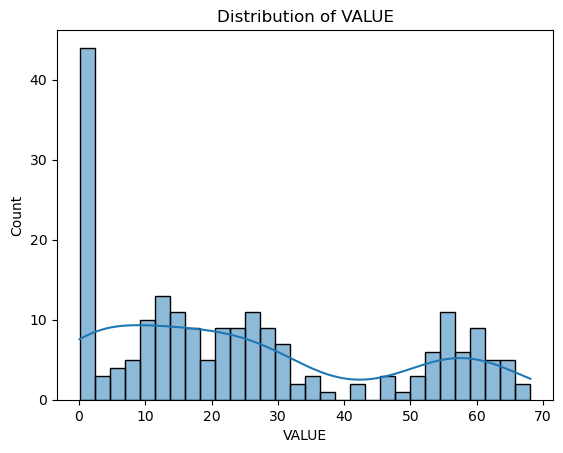

In [32]:
plt.figure()
sns.histplot(df['VALUE'], bins=30, kde=True)
plt.title("Distribution of VALUE")
plt.show()

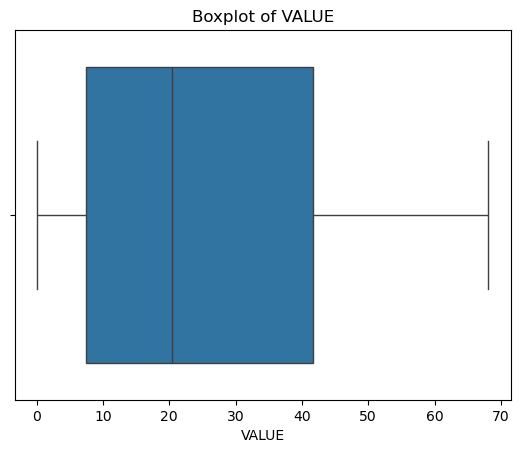

In [15]:
plt.figure()
sns.boxplot(x=df['VALUE'])
plt.title("Boxplot of VALUE")
plt.show()

## Identifying the satisfaction level of VALUE(life Satisfaction)

In [23]:
categorical_cols = df.select_dtypes(include='object').columns.tolist()
print("Categorical Columns:", categorical_cols)


Categorical Columns: ['STATISTIC', 'Statistic_Label', 'Satisfaction_Level', 'Age_Group', 'UNIT']


C:\Users\hp\AppData\Local\Temp\ipykernel_34432\3593585931.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


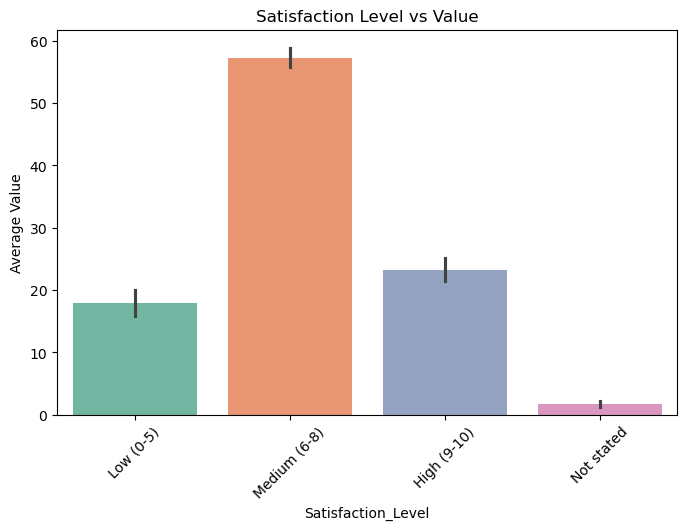

In [34]:
plt.figure(figsize=(8,5))
sns.barplot(
    x='Satisfaction_Level',
    y='VALUE',
    data=df,
    palette='Set2'
)
plt.title("Satisfaction Level vs Value")
plt.xticks(rotation=45)
plt.ylabel("Average Value")
plt.show()

## Identifying the satisfaction level based on Age group vs Value over time

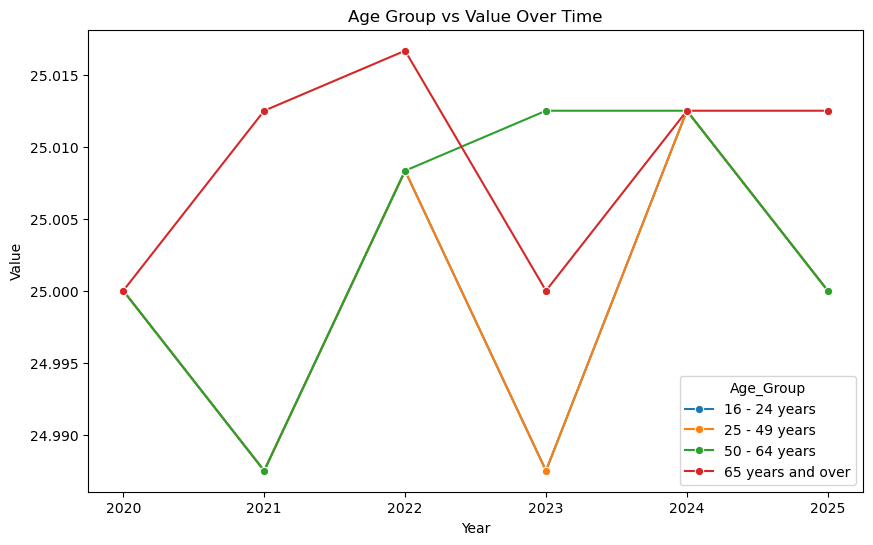

In [28]:
plt.figure(figsize=(10,6))
age_df = df.groupby(['Year', 'Age_Group'])['VALUE'].mean().reset_index()
sns.lineplot(
    x='Year',
    y='VALUE',
    hue='Age_Group',
    data=age_df,
    marker='o'
)
plt.title("Age Group vs Value Over Time")
plt.ylabel("Value")
plt.show()

## Identifying the satisfaction level of VALUE(life Satisfaction) in individuals graph

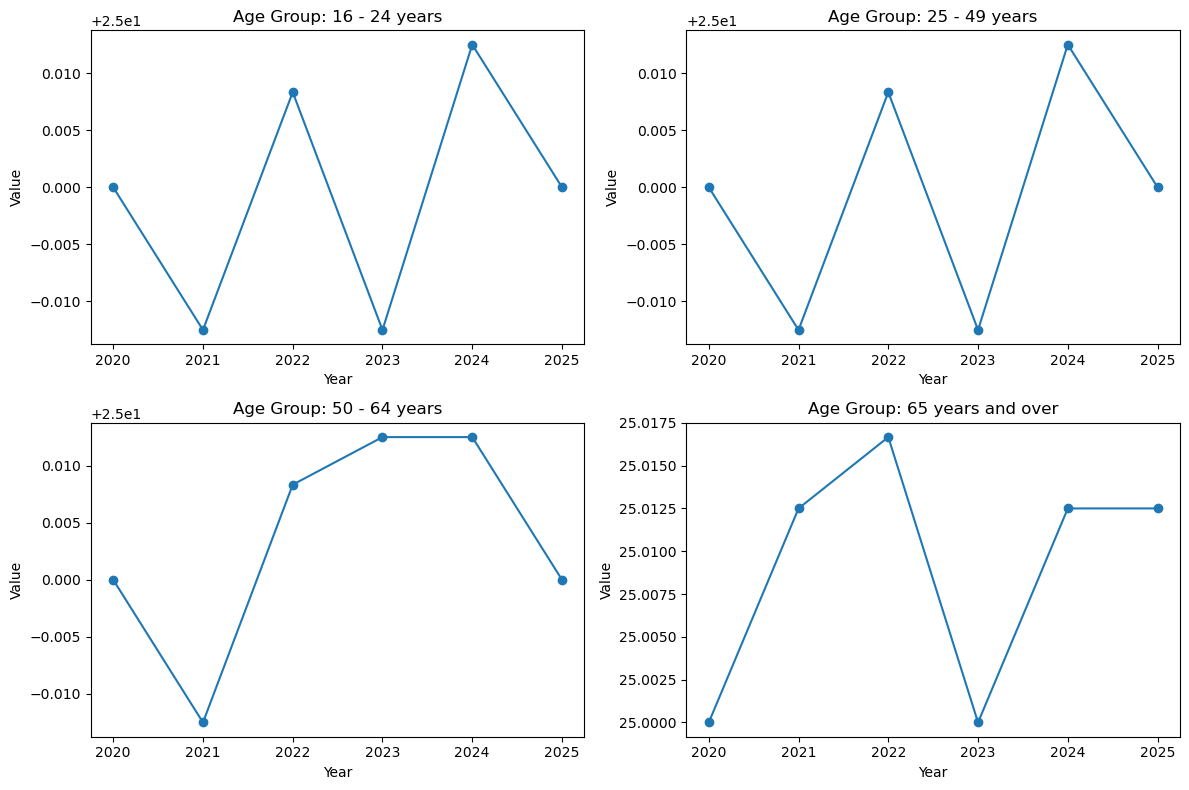

In [27]:
age_df = df.groupby(['Year', 'Age_Group'])['VALUE'].mean().reset_index()
age_groups = age_df['Age_Group'].unique()
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()
for i, age in enumerate(age_groups[:4]): 
    subset = age_df[age_df['Age_Group'] == age]
    axes[i].plot(subset['Year'], subset['VALUE'], marker='o')
    axes[i].set_title(f"Age Group: {age}")
    axes[i].set_xlabel("Year")
    axes[i].set_ylabel("Value")
plt.tight_layout()
plt.show()

C:\Users\hp\AppData\Local\Temp\ipykernel_34432\4131249274.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


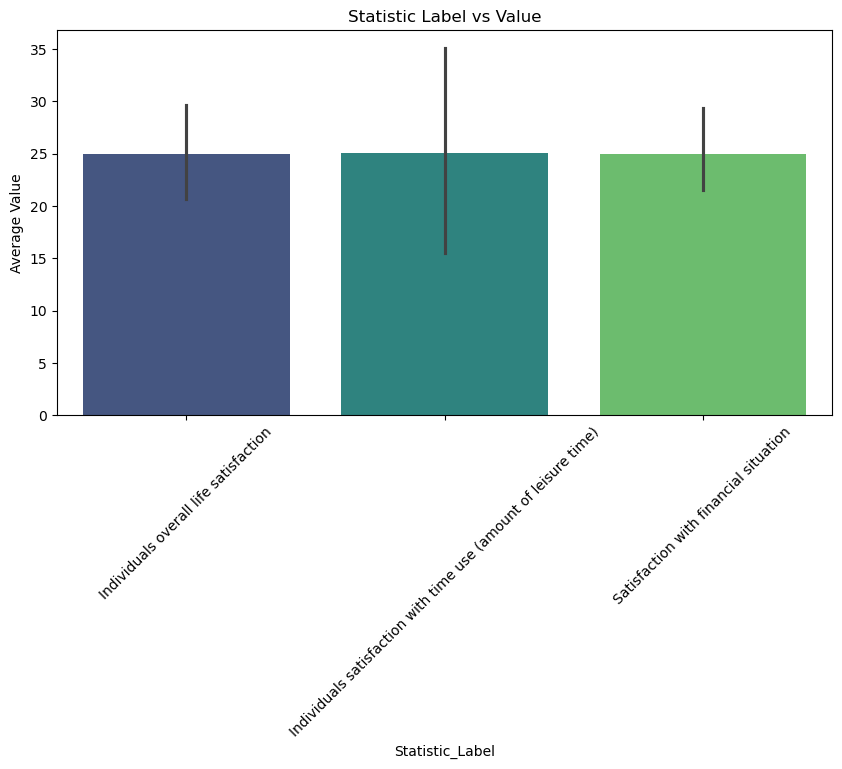

In [20]:
plt.figure(figsize=(10,5))
sns.barplot(
    x='Statistic_Label',
    y='VALUE',
    data=df,
    palette='viridis'
)
plt.title("Statistic Label vs Value")
plt.xticks(rotation=45)
plt.ylabel("Average Value")
plt.show()

## Correlation Matrix of Life Satisfaction

Pivot Table: Satisfaction_Level                                  High (9-10)  Low (0-5)  \
Statistic_Label                                                              
Individuals overall life satisfaction                 26.750000  11.575000   
Individuals satisfaction with time use (amount ...    22.325000  20.875000   
Satisfaction with financial situation                 19.816667  23.608333   

Satisfaction_Level                                  Medium (6-8)  Not stated  
Statistic_Label                                                               
Individuals overall life satisfaction                  60.158333    1.533333  
Individuals satisfaction with time use (amount ...     54.450000    2.400000  
Satisfaction with financial situation                  54.891667    1.687500  


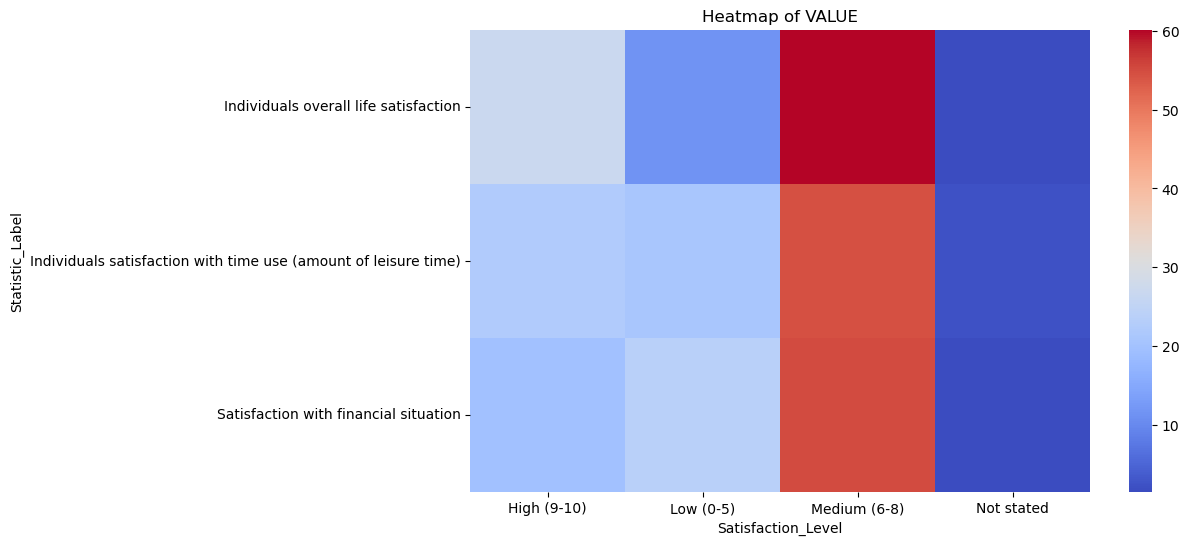


Top 10 VALUE:
     STATISTIC                        Statistic_Label  TLIST(A1)  Year  \
36   WBB64C01  Individuals overall life satisfaction       2022  2022   
21   WBB64C01  Individuals overall life satisfaction       2021  2021   
85   WBB64C01  Individuals overall life satisfaction       2025  2025   
5    WBB64C01  Individuals overall life satisfaction       2020  2020   
69   WBB64C01  Individuals overall life satisfaction       2024  2024   
37   WBB64C01  Individuals overall life satisfaction       2022  2022   
84   WBB64C01  Individuals overall life satisfaction       2025  2025   
20   WBB64C01  Individuals overall life satisfaction       2021  2021   
70   WBB64C01  Individuals overall life satisfaction       2024  2024   
197  WBB64C03  Satisfaction with financial situation       2020  2020   

     C03862V04612 Satisfaction_Level  C02076V02508      Age_Group UNIT  VALUE  
36             20       Medium (6-8)           335  16 - 24 years    %   68.1  
21             20   

In [21]:
safe_cols = [col for col in categorical_cols if col != 'STATISTIC']
if len(safe_cols) >= 1:
    index_col = 'TIME' if 'TIME' in df.columns else safe_cols[0]
    column_col = safe_cols[0] if safe_cols[0] != index_col else safe_cols[1] if len(safe_cols) > 1 else None
    if column_col:
        pivot = pd.pivot_table(df,
                               values='VALUE',
                               index=index_col,
                               columns=column_col,
                               aggfunc='mean')
        
        print("Pivot Table:", pivot.head())
        plt.figure(figsize=(10,6))
        sns.heatmap(pivot, cmap='coolwarm')
        plt.title("Heatmap of VALUE")
        plt.show()

print("\nTop 10 VALUE:\n", df.sort_values(by='VALUE', ascending=False).head(10))
print("\nLowest 10 VALUE:\n", df.sort_values(by='VALUE', ascending=True).head(10))